In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

/Users/varun.tyagi/Documents/workspace/analytics_vidhya/agentic_ai_pioneer/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from getpass import getpass
import os
os.environ["OPENAI_API_KEY"] = getpass("OpenAI Key: ")

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def chatbot(state:State)->State:
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

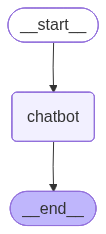

In [5]:
graph

In [6]:
response = graph.invoke({"messages":"Explain FIFA 26 in 2 bullet points"})
response

{'messages': [HumanMessage(content='Explain FIFA 26 in 2 bullet points', additional_kwargs={}, response_metadata={}, id='58521c57-246a-4902-ba0f-3e910c948546'),
  AIMessage(content='- **Expanded Format**: FIFA 26 will feature an expanded tournament format with 48 teams participating, up from 32 in previous editions, allowing for a more diverse representation of nations and increased competition.\n\n- **Host Nations**: The tournament will be jointly hosted by the United States, Canada, and Mexico, marking the first time three countries will co-host the World Cup, and it will also be the first time the event returns to North America since 1994.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 16, 'total_tokens': 111, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'm

In [7]:
response["messages"]

[HumanMessage(content='Explain FIFA 26 in 2 bullet points', additional_kwargs={}, response_metadata={}, id='58521c57-246a-4902-ba0f-3e910c948546'),
 AIMessage(content='- **Expanded Format**: FIFA 26 will feature an expanded tournament format with 48 teams participating, up from 32 in previous editions, allowing for a more diverse representation of nations and increased competition.\n\n- **Host Nations**: The tournament will be jointly hosted by the United States, Canada, and Mexico, marking the first time three countries will co-host the World Cup, and it will also be the first time the event returns to North America since 1994.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 16, 'total_tokens': 111, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider'

In [10]:
print(response["messages"][-1].content)

- **Expanded Format**: FIFA 26 will feature an expanded tournament format with 48 teams participating, up from 32 in previous editions, allowing for a more diverse representation of nations and increased competition.

- **Host Nations**: The tournament will be jointly hosted by the United States, Canada, and Mexico, marking the first time three countries will co-host the World Cup, and it will also be the first time the event returns to North America since 1994.


In [12]:
for event in graph.stream({"messages": "Explain FIFA 2026 to a child in 1 point"},
                          stream_mode="values"):
    print(event["messages"])

[HumanMessage(content='Explain FIFA 2026 to a child in 1 point', additional_kwargs={}, response_metadata={}, id='b4e298af-16ce-4f67-bf94-e30bd042b6c3')]
[HumanMessage(content='Explain FIFA 2026 to a child in 1 point', additional_kwargs={}, response_metadata={}, id='b4e298af-16ce-4f67-bf94-e30bd042b6c3'), AIMessage(content='FIFA 2026 is a big soccer tournament where teams from all over the world come to play and compete to see who is the best at soccer!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 19, 'total_tokens': 50, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ef2d618cea', 'id': 'chatcmpl-Dr5iUJOk2M3fJB4q6465MdvitEpL2', 'service_tier': 'default', 'finish_reason'

In [16]:
for event in graph.stream({"messages": "Explain FIFA 2026 to a child in 1 point"},
                          stream_mode="updates"):
    print(event)

{'chatbot': {'messages': [AIMessage(content='FIFA 2026 is a big soccer tournament where teams from all over the world come together to play and see who is the best at soccer!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 19, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ef2d618cea', 'id': 'chatcmpl-Dr5jKlWsZbTXtSIQLu4J99EosNJVi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ecc67-48d8-7472-8645-8ee0967cceb1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 30, 'total_tokens': 49, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio